<a href="https://colab.research.google.com/github/mcjkurz/qhchina/blob/main/tutorials/Intro_to_Python_for_Chinese_Humanities_Part_2_Working_with_Texts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Python for Chinese Humanities: Part 2, Working with Texts

**Welcome to Part 2 of the Tutorial!**

In this tutorial, we will work with Chinese texts.

We will learn how to segment them into individual words (分詞) and find some basic statistics about the word distribution.

First, let's create a directory (文件夹) called "data," in which we will store our files.

In [1]:
!mkdir data

Click on the "refresh" button to see the new folder.
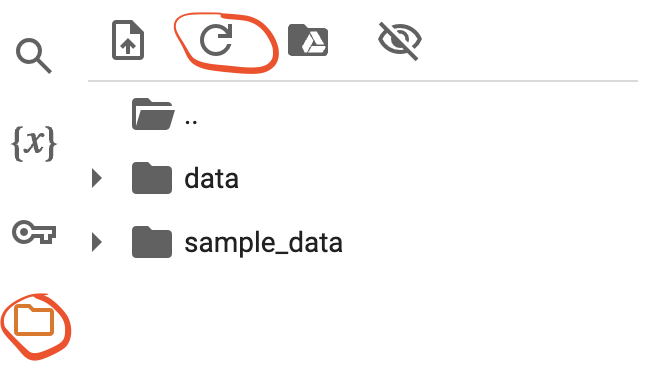

Now, let's download some sample texts into this new directory. To do that, we will use the command `wget`.

**You can also upload your own texts (.txt files).** To do that, simply click on the three dots sign to the right of `data` folder and then click `Upload` (`上传`).

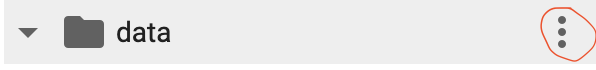

In [2]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_1.txt -P data/
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_2.txt -P data/
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_3.txt -P data/

--2024-09-24 12:14:07--  https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_1.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 126041 (123K) [text/plain]
Saving to: ‘data/GaoErTai_XunzhaoJiayuan_1.txt’

GaoErTai_XunzhaoJia 100%[===================>] 123.09K  --.-KB/s    in 0.03s   

2024-09-24 12:14:07 (4.80 MB/s) - ‘data/GaoErTai_XunzhaoJiayuan_1.txt’ saved [126041/126041]

--2024-09-24 12:14:07--  https://raw.githubusercontent.com/mcjkurz/qhchina/refs/heads/main/tutorials/data/GaoErTai_XunzhaoJiayuan_2.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199

Now, we need to create a list of filenames. This list is required because we will be reading from the downloaded files, one by one, in a loop.

The list of filenames can be found with the help of `os` library.

Specifically, the function `os.listdir(directory)` returns a list of filenames in this specified `directory.`

**We will only consider the .txt files.** To remove everything else, we will use the in-built function `.endswith()`.

In [3]:
import os
filenames = [filename for filename in os.listdir("data") if filename.endswith(".txt")]
print(filenames)

['GaoErTai_XunzhaoJiayuan_3.txt', 'GaoErTai_XunzhaoJiayuan_1.txt', 'GaoErTai_XunzhaoJiayuan_2.txt']


Now, we will read these files, one by one. **We will need to append the prefix `data/` to each filename, so that the computer can find them.**

We use the `open` function to read files.

`open` takes many arguments. We will provide three:

1. the full filename **(including the `data/` prefix)**,
2. the mode of access to this file (`"r"` for "read")
3. encoding (`UTF-8`).

We need to remember to `close` the file reader after we finish reading from file.

After reading each .txt file, we will append its content (the text) to our list `texts`.

In [4]:
import os

texts = [] # empty list, we will append to it in a loop

for filename in filenames:
  full_filename = "data/" + filename # we add the prefix!
  print("Reading " + full_filename + "...")

  file_reader = open(full_filename, "r", encoding="UTF-8")
  text = file_reader.read()
  file_reader.close()

  print("Finished!")
  texts.append(text)

print("I have loaded " + str(len(texts)) + " files.")

Reading data/GaoErTai_XunzhaoJiayuan_3.txt...
Finished!
Reading data/GaoErTai_XunzhaoJiayuan_1.txt...
Finished!
Reading data/GaoErTai_XunzhaoJiayuan_2.txt...
Finished!
I have loaded 3 files.


In [5]:
print("How many characters (including spaces) in the first file:", len(texts[0]))

How many characters (including spaces) in the first file: 273745


In [6]:
print(texts[0][:200]) # print the first 200 characters of the first file.

卷三 天苍地茫
天空地⽩
⼀九六四年，茨林在敦煌中学上⾼中，梳着个马尾巴髻，⽆忧⽆虑，
爱说爱笑，爱跑爱跳。暑假⾥，跟着她的⽗亲，著名医⽣、敦煌医院院长
李瑶甫先⽣出诊，到莫⾼窟来玩。这个沙漠中的⽯窟寺群，她从没来过。
⽗亲⼯作时，⼀个⼈到处跑到处看。在悬崖峭壁上四百多个洞⼦⾥上⾼下
低钻来钻去。
我在洞中临摹古画，⽇⽇⾯壁，不见⼈影，都快变成达摩了。突然闯
进⼀个美丽的少⼥，不由得眼睛⼀亮。她天


Notice that the texts need some editing and pre-processing. For example, the sentences are broken into lines, often incorrectly.

Let's remove the line-breakers using a simple trick. We first use the in-built `.split()` function to split the text into individual lines. Then, we will use `"".join()` function to bring them back again into a very long string.

Before doing this on our texts, consider this simple example:

In [7]:
text_with_many_lines = """這是第一行。
這是第二行。
這是第三行。"""
print(text_with_many_lines) # one string, with lines separated by line-breakers

這是第一行。
這是第二行。
這是第三行。


Now, we use the `.split()` function.

In [8]:
list_of_lines = text_with_many_lines.split()
print(list_of_lines) # list with three elements

['這是第一行。', '這是第二行。', '這是第三行。']


Now, we combine the lines into one single string (字串) using the `"".join()` function.

In [9]:
lines_combined = "".join(list_of_lines)
print(lines_combined) # one string

這是第一行。這是第二行。這是第三行。


We will use this trick to do the same with our texts.

We use a loop, and for each text, we first split it with `.split()` function and then join it with the `"".join()` function.

In [10]:
for index in range(len(texts)):
  texts[index] = "".join(texts[index].split())

In [11]:
print(texts[0][:200]) # again, let's print the first 200 characters of the first file.

卷三天苍地茫天空地⽩⼀九六四年，茨林在敦煌中学上⾼中，梳着个马尾巴髻，⽆忧⽆虑，爱说爱笑，爱跑爱跳。暑假⾥，跟着她的⽗亲，著名医⽣、敦煌医院院长李瑶甫先⽣出诊，到莫⾼窟来玩。这个沙漠中的⽯窟寺群，她从没来过。⽗亲⼯作时，⼀个⼈到处跑到处看。在悬崖峭壁上四百多个洞⼦⾥上⾼下低钻来钻去。我在洞中临摹古画，⽇⽇⾯壁，不见⼈影，都快变成达摩了。突然闯进⼀个美丽的少⼥，不由得眼睛⼀亮。她天真⽆邪，毫不认⽣。


Hurray! The line breakers are gone!

## Word segmentation for Chinese

Unlike English, in Chinese there are no spaces between words. This poses a problem for text analysis.

For very short texts, we can segment them into separate tokens (words) ourselves.

In [12]:
text = "我今天很开心。"
word_list = ["我", "今天", "很", "开心","。"]
print(len(word_list))

5


In [13]:
for word in word_list:
  print(word)

我
今天
很
开心
。


For larger texts, however, we need some help.

Fortunately, there **are free, open-source models that we can use to segment Chinese texts.**

In this example, we will use `spacy` model for Chinese, `zh_core_web_lg`.

Let's first download and load the model. This might take around 30 seconds.

In [14]:
!python -m spacy download zh_core_web_lg
import spacy
nlp = spacy.load("zh_core_web_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.0/603.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Let's now segment our short example sentence ("我今天很開心") using the model we have just downloaded.

To do that, we can use the function `nlp` and provide the text as the argument.

The function `nlp` will return a list of tokens (words). Each token in this list has some important properties. We will use two of them:

*   `token.text` -- this is the actual word
*   `token.pos_` -- this is the part-of-speech tag of this word (noun, verb, etc).

Let's try!


In [15]:
sentence = "我今天很开心。"

segmented_sentence = nlp(sentence) # this will return a list of tokens
print([token.text for token in segmented_sentence]) # let's print a list of words

['我', '今天', '很', '开心', '。']


**Part-of-Speech (POS)** is a very useful category. For example, we might want to remove all punctuation marks (。，“； etc.) from our list of words.

Each token has its tag (called POS-tag). We can access it through `.pos_`. The full list of tags can be seen here: https://universaldependencies.org/u/pos/

In [16]:
print([token.pos_ for token in segmented_sentence])

['PRON', 'NOUN', 'ADV', 'VERB', 'PUNCT']


Let's combine two properties and print them in a loop.

In [17]:
for token in segmented_sentence:
  print("Token: " + token.text + ", part-of-speech: " + token.pos_)

Token: 我, part-of-speech: PRON
Token: 今天, part-of-speech: NOUN
Token: 很, part-of-speech: ADV
Token: 开心, part-of-speech: VERB
Token: 。, part-of-speech: PUNCT


The model is roughly correct.
* "我" is a pronoun (PRON),
* "今天" is a noun (NOUN),
* "很" is an adverb (ADV),
etc.

Let's now go back to our `texts`. As you remember, each element in `texts` is a very long string, without line-breakers.

We will separate these strings, one by one, into individual tokens, removing punctuation, spaces, and special symbols (if any).

This might take some time (even a few minutes), depending on the size of your files. Notice that I also truncate (cut) the text if it is longer than the `max_length` set by `nlp`.

*This process can be made faster by providing additional argument to `nlp`: disable=['parser','ner'].*

In [18]:
segmented_texts = []

excluded_pos = ["PUNCT", "SYM", "SPACE"] # the tags we want to remove (can add yours; maybe you want to focus on verbs only?)

for text in texts:
  if len(text) > nlp.max_length:
    text = text[:nlp.max_length] # only the first nlp.max_length tokens (this is a huge number so no worries)
  segmented_text = nlp(text)
  text_tokens = [token.text for token in segmented_text if token.pos_ not in excluded_pos]
  segmented_texts.append(text_tokens)

Let's now print the first 100 tokens from our first segmented text.

In [20]:
print(segmented_texts[0][:100])

['卷三', '天', '苍地', '茫天', '空地', '⽩⼀', '九六四年', '茨林', '在', '敦煌', '中学', '上', '⾼', '中', '梳', '着', '个', '马尾巴髻', '⽆忧', '⽆虑', '爱', '说', '爱笑', '爱', '跑', '爱跳', '暑假', '⾥', '跟着', '她', '的', '⽗亲', '著名', '医⽣', '敦煌', '医院', '院长', '李瑶甫', '先⽣', '出诊', '到', '莫⾼窟', '来', '玩', '这个', '沙漠', '中', '的', '⽯窟', '寺群', '她', '从没', '来', '过', '⽗亲', '⼯作', '时', '⼀', '个', '⼈到', '处跑', '到处', '看', '在', '悬崖', '峭壁', '上', '四百多', '个', '洞⼦⾥', '上', '⾼下', '低钻', '来', '钻去', '我', '在', '洞', '中', '临摹', '古画', '⾯壁', '不见', '⼈影', '都', '快', '变成', '达摩', '了', '突然', '闯进', '⼀', '个', '美丽', '的', '少⼥', '不由得', '眼睛', '⼀亮', '她']


You can see that the model is often correct, but there are mistakes.

## Finding most common words



In this section, we will learn how to find the most common words in our dataset.

First, let's combine all segmented texts into one huge list. We will call it `all_tokens`.

The `all_tokens` list will contain all words (tokens) from all our texts combined together.

In [21]:
all_tokens = []
for segmented_text in segmented_texts:
  all_tokens += segmented_text

print("In total, there are " + str(len(all_tokens)) + " tokens.")

In total, there are 222565 tokens.


Now, let's find the most frequent tokens.

We will use the library `collections` and the class `Counter` from this library.

We can use `Counter` as a function, providing the tokens as its argument.

In [22]:
from collections import Counter

token_counter = Counter(all_tokens)
token_counter.most_common(20) # print the 20 most common tokens

[('的', 13172),
 ('了', 4948),
 ('我', 4757),
 ('是', 3855),
 ('在', 2901),
 ('不', 2604),
 ('他', 2574),
 ('说', 2178),
 ('和', 1767),
 ('也', 1741),
 ('个', 1735),
 ('⼀', 1706),
 ('有', 1683),
 ('都', 1674),
 ('⼈', 1517),
 ('着', 1386),
 ('就', 1342),
 ('你', 1236),
 ('我们', 1084),
 ('上', 1039)]

We see that some of the most frequent words are the so-called "function words": 的, 了, 是, 著, etc.

We can check how many times a token shows up by looking up its value in the dictionary `token_counter`.

In [23]:
print(token_counter["中国"])
print(token_counter["我"])
print(token_counter["abc"]) # "abc" should appear 0 times

220
4757
0


As noted previously, many of the most frequent words are the so-called "stopwords": words with little meaning. We can remove them from the list to find more "informative" words.

To do that, we need a list of Chinese stopwords. We can find it using the `nltk` library.

We can also add our own `custom_stopwords`.

In [24]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stopwords = stopwords.words('chinese')
print(stopwords[:10]) # print the first 10 stopwords from the list

# we can also add custom stopwords:
custom_stopwords = ["⼀个", "这是", "东西"]
stopwords = stopwords + custom_stopwords

['一', '一下', '一些', '一切', '一则', '一天', '一定', '一方面', '一旦', '一时']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Now, we can use this list of stopwords to filter the most common words and keep only the non-stopwords.

We can also decide to keep only the words with at least two characters or longer.

The `token_counter.most_common(1000)` will return a list of 1000 elements.

Each element is a tuple `(token, frequency)`, for example the first element (most common) is `('的', 13173)`.

In the following line, we take the most common 1000 tokens, we filter out (remove) stopwords, and we keep only the tokens that are at least two characters long.

In [25]:
informative_tokens = [(token, frequency) for (token, frequency) in token_counter.most_common(1000) if token not in stopwords and len(token) > 1]
print(informative_tokens)

[('历史', 277), ('高尔泰', 245), ('中国', 220), ('社会', 196), ('⼤家', 193), ('世界', 192), ('敦煌', 190), ('艺术', 188), ('母亲', 182), ('先⽣', 181), ('⽣活', 179), ('⾃然', 171), ('⾃由', 164), ('⼀次', 161), ('⼀种', 160), ('⼀些', 152), ('政治', 150), ('⼀样', 148), ('⼀切', 148), ('时间', 148), ('本质', 148), ('⼀直', 146), ('回来', 146), ('劳动', 146), ('⼀下', 143), ('⾰命', 140), ('精神', 140), ('哲学', 133), ('感觉', 131), ('⼤学', 129), ('美学', 129), ('⼈类', 126), ('喜欢', 124), ('⼈们', 123), ('想到', 123), ('⽗亲', 122), ('思想', 122), ('兰州', 122), ('孩⼦', 118), ('⼀起', 116), ('⽂章', 116), ('创造', 116), ('⽂化', 114), ('⼯作', 113), ('⾥⾯', 111), ('告诉', 111), ('美的', 108), ('第⼀', 106), ('第⼆', 105), ('地⽅', 105), ('⼀点', 105), ('感到', 104), ('农场', 103), ('⽂⾰', 103), ('只能', 103), ('之间', 102), ('眼睛', 101), ('发现', 101), ('研究', 101), ('关系', 101), ('⼩⾬', 101), ('朋友', 100), ('酒泉', 100), ('意义', 100), ('条件', 99), ('别⼈', 95), ('北京', 95), ('⼀天', 90), ('价值', 89), ('不知', 88), ('客观', 88), ('⼆⼗', 87), ('对象', 86), ('⼀定', 84), ('学校', 83), ('说话', 83), ('阶级', 83), ('好像', 82)

## Making a wordcloud from the "informative" tokens

We need to first download the Chinese font, as Python does not support Chinese language visualization by default.

In [26]:
!wget https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf

--2024-09-24 12:16:51--  https://raw.githubusercontent.com/mcjkurz/qhchina/main/tutorials/data/STSong.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11697600 (11M) [application/octet-stream]
Saving to: ‘STSong.ttf’

STSong.ttf          100%[===================>]  11.16M  --.-KB/s    in 0.1s    

2024-09-24 12:16:51 (100 MB/s) - ‘STSong.ttf’ saved [11697600/11697600]



You can read more about the WordCloud class here: https://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html

You can choose different color maps: https://matplotlib.org/stable/gallery/color/colormap_reference.html . I chose `plasma`.

The following code will generate a wordcloud and save it as "wordcloud.png" in the local directory. You can download it to your computer.

If you don't like the final result, you can run the code as many times as you wish.

In [27]:
informative_tokens[:10]

[('历史', 277),
 ('高尔泰', 245),
 ('中国', 220),
 ('社会', 196),
 ('⼤家', 193),
 ('世界', 192),
 ('敦煌', 190),
 ('艺术', 188),
 ('母亲', 182),
 ('先⽣', 181)]

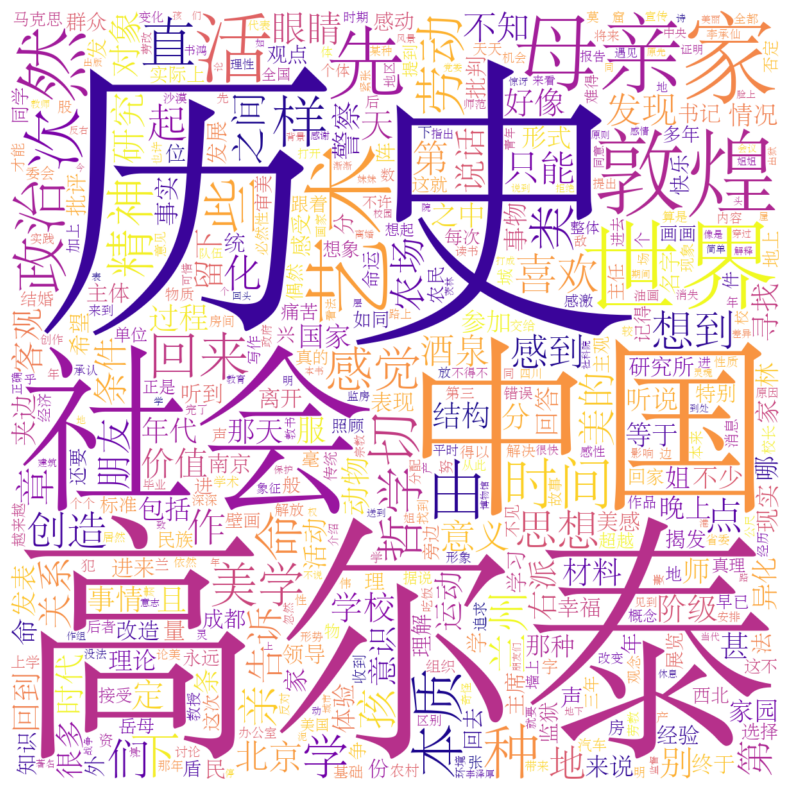

In [29]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Convert back to a dictionary (WordCloud requires a dictionary)
frequencies_dict = dict(informative_tokens)

# Generate word cloud
wordcloud = WordCloud(font_path='STSong.ttf',
                      colormap="plasma",
                      max_words=500,
                      width=1200,
                      height=1200,
                      background_color='white')

wordcloud.generate_from_frequencies(frequencies_dict)

# Display the generated word cloud
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("wordcloud.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

That's the end of this tutorial. Congratulations!